In [46]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [47]:
import pandas as pd
pd.set_option("display.max_colwidth", None)

from src.data_loader import load_train_reviews

reviews = load_train_reviews()

## Dataset Overview

In [48]:
reviews.shape

(838944, 11)

In [49]:
reviews.head()

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime
0,2,NaN,False,2016-11-11,A2OSUEZJIN7BI,0511189877,NaN,Chris,"I have an older URC-WR7 remote and thought this would be an upgrade (and because TWC stuck me with it), but this one fails where the other one didn't. The old remote could go head to head and learn. I have 2 different Blu Ray players (LG & Panasonic) and this one fails on both. It cannot learn buttons. The biggest problem is in streaming when I need to hit the blue, red, yellow, green buttons. These cannot work either of them, so I have to pull out the remote for that one setting. I don't know why they give you multiple code methods but no learning.",Cannot Learn,1478822400
1,5,NaN,True,2016-06-06,A2NETQRG6JHIG7,0511189877,NaN,Qrysta White,First time I've EVER had a remote that needed no programming whatsoever so I have to give it bragging rights. All the other 8780Ls I've had certainly had to be set up first.\n\nYes I wish it was Silver or White or some color that would permit its buttons to be more easily read but its thinner in hand than the ATLAS OCAP 5-Device Cable Remote Control 1056B03 so its the best thing I can find for a Samsung DVR with Samsung TV on the TWC system in NY.,zero programming needed! Miracle!?,1465171200
2,4,NaN,True,2016-03-10,A12JHGROAX49G7,0511189877,NaN,Linwood,Got them and only 2 of them worked. company called me after the feedback and told me they would send me a refund. The 2 that are working are doing fine. I like the lighted feature a lot for the night time.,Works Good and programs easy.,1457568000
3,5,NaN,True,2016-01-14,A1KV65E2TMMG6F,0511189877,NaN,Dane Williams,"I got tired of the remote being on the wrong side of the bed. I was going to buy a generic remote when I got the idea to look for the real thing. For a few bucks more I got this one. It is the same one as Time Warner gives you, works exactly the same, don't have to relearn anything.",Same as TWC remote,1452729600
4,5,NaN,True,2016-10-20,A280POPEWI0NSA,0594459451,NaN,Kristina H.,"After purchasing cheap cords from another website, I was a little scared to purchase. So glad I did though! It works great and the design will keep the cord from breaking so easily. Price is still kind of high for a power cord but it is worth it.",Good Quality Cord,1476921600


In [50]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 838944 entries, 0 to 838943
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   overall         838944 non-null  int64 
 1   vote            191468 non-null  object
 2   verified        838944 non-null  bool  
 3   reviewTime      838944 non-null  str   
 4   reviewerID      838944 non-null  str   
 5   asin            838944 non-null  str   
 6   style           490613 non-null  str   
 7   reviewerName    838717 non-null  str   
 8   reviewText      838944 non-null  str   
 9   summary         838868 non-null  str   
 10  unixReviewTime  838944 non-null  int64 
dtypes: bool(1), int64(2), object(1), str(7)
memory usage: 64.8+ MB


In [51]:
reviews.describe(include="all")

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime
count,838944.000000,191468.0,838944,838944,838944,838944,490613,838717,838944,838868,8.389440e+05
unique,NaN,861.0,2,1007,321135,90715,40887,234102,807611,696896,NaN
top,NaN,2.0,True,2016-01-04,A680RUE1FDO8B,B010OYASRG,{'Color:': ' Black'},Amazon Customer,"Love these!!!. Got one for front & back of house. I don't use the batteries, cause I don't want to be climbing the ladder changing batteries. I have one at the front door entryway corner 10' up, so you can't really examine it. I have had a few friends notice them & thought they were real. Had a security guy come out for estimate of a real camera, & he said ""why do you want a camera here, you already have one""? I told him it was fake. I'm sure the battery, to make the red light flash would make it more realistic, but I as I said, I don't want to draw attention by climbing a ladder & changing the battery all the time.",Five Stars,NaN
freq,NaN,37154.0,720389,1976,158,1853,43589,24896,43,957,NaN
mean,4.021317,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.483167e+09
std,1.344223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.229270e+07
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.451606e+09
25%,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.464653e+09
50%,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.479254e+09
75%,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.499472e+09


In [52]:
reviews.sample(5, random_state=42)

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime
479970,4,NaN,True,2016-07-12,AX7MXA975XBAV,B010H0SL9O,NaN,David,"I really like this product! The only reason I took off one star is because 1) the instruction booklet is a bit cheesy, 2) The rubber ""bands"" that hold it to the mirror are sure to fail sitting in the hot Florida sunshine 3) The back up camera isn't the easiest to install, but then again many of it's competitors don't even have a back-up camera.\nYou need to buy an SD card for this unit. The supplied cables are amazingly long enough.\nOverall I'm very happy with the unit and the image quality is very good.",Good Product. I just got one for my wife's and daughters cars,1468281600
529489,5,NaN,True,2016-10-03,A24LUA312PIIG5,B014M8ZO92,"{'Color:': ' Phantom Edition', 'Style:': ' Core Lineup'}",Cobra GT,"these are better than the Boom ones, pricey though<a data-hook=""product-link-linked"" class=""a-link-normal"" href=""/UE-BOOM-2-Phantom-Wireless-Mobile-Bluetooth-Speaker-Waterproof-and-Shockproof/dp/B014M8ZO8S/ref=cm_cr_arp_d_rvw_txt?ie=UTF8"">UE BOOM 2 Phantom Wireless Mobile Bluetooth Speaker (Waterproof and Shockproof)</a>",these are better than the Boom ones,1475452800
380130,5,NaN,True,2018-03-19,AN94QSQUJF627,B00RH29CJO,NaN,MikeM,"Just got a new-to-me 2013 Mazda MX-5, and forgot it was from the era where Bluetooth was still an option. Needed some sort of hands-free. I had all the stuff I needed to replace the stock head-unit with one that had SIRIUSXM, including a premade harness and the installation kit. That was Crutchfield, which I know from previous experience is great. But it was $266. So I ordered this instead. Works great. I don't need satellite that badly. Haven't tried it with the top down yet. I assume that won't be very good. No big deal.","High build quality, syncs to my S8 quickly, five minute install.",1521417600
568335,5,NaN,True,2016-05-21,AX5E1Q0LNLOHG,B016UBLTMK,{'Color:': ' Chevron Gray'},Fiapop,"Terrific case. Stylish and very soft inside.\n\nI want to comment on the Customer Service. Very quick response, and really put the customer ""myself"" first. I am very happy with the purchase and the service experience",Great Customer Service!,1463788800
355122,5,NaN,True,2017-02-27,A3M5CEQWC2ENSS,B00P31BMHG,{'Size:': ' The Anchor'},Daniel Kang,Came quick and does what it is supposed to. Definitely has a better 3M tape on it than some of the cheaper ones I've tried. Holds my HyperX and Beats wireless perfectly fine. Would recommend to anyone looking for a under-desk style headphone mount. Do not waste your money on some of these cheaper ones out there.,Perfect!,1488153600


## Target Variable Analysis

In [53]:
reviews["overall"].unique()

array([2, 5, 4, 3, 1])

In [54]:
reviews["overall"].value_counts().sort_index()

overall
1     82950
2     56756
3     81239
4    156514
5    461485
Name: count, dtype: int64

In [55]:
(reviews["overall"].value_counts(normalize=True).sort_index() * 100)

overall
1     9.887430
2     6.765171
3     9.683483
4    18.656072
5    55.007843
Name: proportion, dtype: float64

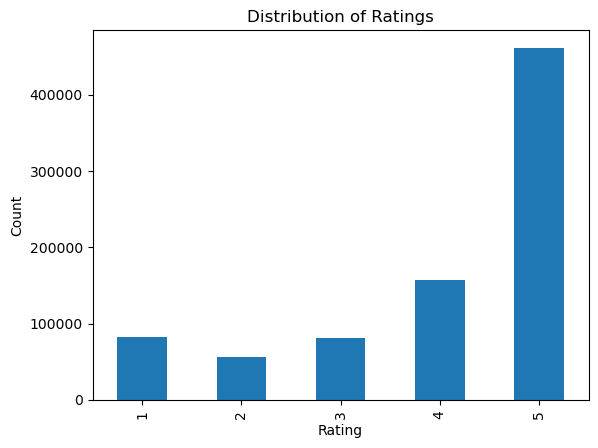

In [56]:
import matplotlib.pyplot as plt

reviews["overall"].value_counts().sort_index().plot.bar()

plt.xlabel("Rating")

plt.ylabel("Count")

plt.title("Distribution of Ratings")

plt.show()

## Duplicate Analysis

In [57]:
reviews.duplicated().sum()

np.int64(8327)

In [58]:
reviews["reviewText"].duplicated().sum()

np.int64(31333)

In [59]:
reviews["reviewerID"].duplicated().sum()

np.int64(517809)

In [60]:
reviews["asin"].duplicated().sum()

np.int64(748229)

## Text Quality Analysis

In [61]:
reviews["reviewText"].isna().sum()

np.int64(0)

In [62]:
reviews["summary"].isna().sum()

np.int64(76)

In [63]:
empty_reviews = reviews["reviewText"].fillna("").str.strip().eq("").sum()
print(empty_reviews)

0


In [64]:
reviews["word_count"] = reviews["reviewText"].str.split().str.len()

In [65]:
reviews["word_count"].describe()

count    838944.000000
mean        115.130382
std         123.351430
min           1.000000
25%          52.000000
50%          76.000000
75%         129.000000
max        5144.000000
Name: word_count, dtype: float64

In [66]:
reviews["word_count"].quantile([0.90, 0.95, 0.99])

0.90    223.0
0.95    316.0
0.99    613.0
Name: word_count, dtype: float64

In [67]:
reviews.loc[
    reviews["word_count"] > reviews["word_count"].quantile(0.99), "reviewText"
].head()

358                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [76]:
reviews.loc[
    reviews["word_count"] < reviews["word_count"].quantile(0.00001), "reviewText"
].head()

124132    https://www.amazon.com/s/ref=w_bl_sl_s_ap_web_7141123011?ie=UTF8&node=7141123011&field-brandtextbin=iT-Shirts\n\nhttps://www.amazon.com/s/ref=w_bl_sl_s_ap_web_7141123011?ie=UTF8&node=7141123011&field-brandtextbin=iT-Shirts\n\nhttps://www.amazon.com/s/ref=w_bl_sl_s_ap_web_7141123011?ie=UTF8&node=7141123011&field-brandtextbin=iT-Shirts\n\nhttps://www.amazon.com/s/ref=w_bl_sl_s_ap_web_7141123011?ie=UTF8&node=7141123011&field-brandtextbin=iT-Shirts
240706    https://www.amazon.com/s/ref=w_bl_sl_s_ap_web_7141123011?ie=UTF8&node=7141123011&field-brandtextbin=iT-Shirts\n\nhttps://www.amazon.com/s/ref=w_bl_sl_s_ap_web_7141123011?ie=UTF8&node=7141123011&field-brandtextbin=iT-Shirts\n\nhttps://www.amazon.com/s/ref=w_bl_sl_s_ap_web_7141123011?ie=UTF8&node=7141123011&field-brandtextbin=iT-Shirts\n\nhttps://www.amazon.com/s/ref=w_bl_sl_s_ap_web_7141123011?ie=UTF8&node=7141123011&field-brandtextbin=iT-Shirts
255786                                                                            

In [77]:
reviews.loc[
    reviews["word_count"] < reviews["word_count"].quantile(0.0001), "reviewText"
].head()

3840     <a data-hook="product-link-linked" class="a-link-normal" href="/Belkin-6-Outlet-SurgeMaster-Wall-Mount-Surge-Protector-F9H620-CW/dp/B00006BBAC/ref=cm_cr_arp_d_rvw_txt?ie=UTF8">Belkin 6-Outlet SurgeMaster Wall-Mount Surge Protector, F9H620-CW</a>&nbsp;Works great for phones, chargers, etc.
17015                                                                                            WORKS GREAT, GOOD QUALITY ALSO!!!!!!!<a data-hook="product-link-linked" class="a-link-normal" href="/Will-The-Forest-Be-Saved/dp/B008JO2QEW/ref=cm_cr_arp_d_rvw_txt?ie=UTF8">Will The Forest Be Saved</a>
22989                                                                                        The&nbsp;<a data-hook="product-link-linked" class="a-link-normal" href="/Thumbprint-Security-USB-Reader/dp/B000HHHP7C/ref=cm_cr_arp_d_rvw_txt?ie=UTF8">Thumbprint Security USB Reader</a>&nbsp;works awesome!
26742                                                          Fit perfectly to my Koss Porta Pro headp

In [81]:
reviews.loc[
    reviews["word_count"] < reviews["word_count"].quantile(1), "reviewText"
].head()

0    I have an older URC-WR7 remote and thought this would be an upgrade (and because TWC stuck me with it), but this one fails where the other one didn't.  The old remote could go head to head and learn.  I have 2 different Blu Ray players (LG & Panasonic) and this one fails on both.  It cannot learn buttons.  The biggest problem is in streaming when I need to hit the blue, red, yellow, green buttons.  These cannot work either of them, so I have to pull out the remote for that one setting.  I don't know why they give you multiple code methods but no learning.
1                                                                                                                 First time I've EVER had a remote that needed no programming whatsoever so I have to give it bragging rights.  All the other 8780Ls I've had certainly had to be set up first.\n\nYes I wish it was Silver or White or some color that would permit its buttons to be more easily read but its thinner in hand than the ATLAS O

In [23]:
import re

reviews["sentence_count"] = reviews["reviewText"].apply(
    lambda x: len(re.findall(r"[.!?]+", str(x)))
)

In [24]:
reviews["sentence_count"].describe()

count    838944.000000
mean          7.746794
std           7.642617
min           0.000000
25%           4.000000
50%           6.000000
75%           9.000000
max         614.000000
Name: sentence_count, dtype: float64

In [25]:
reviews["reviewText"].str.contains(r"<.*?>", regex=True, na=False).sum()

np.int64(17129)

In [35]:
reviews.loc[
    reviews["reviewText"].str.contains(r"<.*?>", regex=True, na=False), "reviewText"
].head()

118    I bought the unit. Since the beginning I had t...
155    My Wife & I are in the stage of life where we ...
351    Bottom Line:  I love this radio.  If you are l...
472    I got these to replace my&nbsp;<a data-hook="p...
547    Pros:\n- Loud\n- Lightweight as advertised\n- ...
Name: reviewText, dtype: str

In [26]:
reviews["reviewText"].str.contains(r"http[s]?://", regex=True, na=False).sum()

np.int64(9380)

In [36]:
reviews.loc[
    reviews["reviewText"].str.contains(r"http[s]?://", regex=True, na=False), "reviewText"
].head(10)

1273    Used on our trip to the beach.  Haven't develo...
1755    I have used Tiffen UV filters for years, they ...
1835    Purchased this item along with The Quick-Chang...
1917    I have used Tiffen UV filters for years, they ...
1997    Purchased this item along with The Quick-Chang...
2060    <div id="video-block-RAAIWRKOK6QXM" class="a-s...
2133    Worked really well, but accidentally bumped it...
2447    <div id="video-block-R10T3H2GXWFYAF" class="a-...
2462    This capture card is Ok, it performs well on c...
2485    A great product. Took me a bit to get used to ...
Name: reviewText, dtype: str

In [27]:
import re

special = reviews["reviewText"].apply(
    lambda x: len(re.findall(r"[^a-zA-Z0-9\s.,!?]", str(x)))
)

special.describe()

count    838944.000000
mean          6.921740
std          17.401352
min           0.000000
25%           1.000000
50%           3.000000
75%           6.000000
max        1948.000000
Name: reviewText, dtype: float64

In [28]:
reviews["uppercase_ratio"] = reviews["reviewText"].apply(
    lambda x: sum(c.isupper() for c in str(x)) / max(len(str(x)), 1)
)

reviews["uppercase_ratio"].describe()

count    838944.000000
mean          0.031333
std           0.031921
min           0.000000
25%           0.018667
50%           0.025641
75%           0.036437
max           0.827586
Name: uppercase_ratio, dtype: float64